In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from deepface import DeepFace
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
DATA_PATH = "data/raw_50_images/"

In [3]:
def load_dataset(dataset_path):
    images = []
    labels = []
    label_map = {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)

        if not os.path.isdir(person_path):
            continue

        label_map[current_label] = person_name

        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(current_label)

        current_label += 1

    return np.array(images), np.array(labels), label_map

X, y, label_map = load_dataset(DATA_PATH)

print("Dataset shape:", X.shape)
print("Number of classes:", len(label_map))

Dataset shape: (1560, 250, 250, 3)
Number of classes: 12


In [4]:
IMG_SIZE = (160, 160)

def preprocess(img):
    img = cv2.resize(img, IMG_SIZE)
    return img

In [5]:
def extract_embeddings(images):
    embeddings = []

    for img in images:
        img = preprocess(img)

        try:
            rep = DeepFace.represent(
                img_path = img,
                model_name = "Facenet512",   # thay bằng Facenet nhan Thịnh
                enforce_detection = False
            )

            emb = rep[0]["embedding"]
            embeddings.append(emb)

        except:
            continue

    return np.array(embeddings)

X_emb = extract_embeddings(X)

print("Embedding shape:", X_emb.shape)

Embedding shape: (1560, 512)


In [6]:
min_len = min(len(X_emb), len(y))
X_emb = X_emb[:min_len]
y = y[:min_len]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
norm = Normalizer(norm='l2')
X_train = norm.fit_transform(X_train)
X_test = norm.transform(X_test)

In [9]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 12)                1548      
                                                                 
Total params: 165772 (647.55 KB)
Trainable params: 165772 (647.55 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
32/32 [==============================] - 1s 9ms/step - loss: 1.6510 - accuracy: 0.5621 - val_loss: 0.8232 - val_accuracy: 0.8000
Epoch 2/30
32/32 [==============================] - 0s 4ms/step - loss: 0.4594 - accuracy: 0.9279 - val_loss: 0.2104 - val_accuracy: 0.9720
Epoch 3/30
32/32 [==============================] - 0s 4ms/step - loss: 0.1631 - accuracy: 0.9729 - val_loss: 0.1400 - val_accuracy: 0.9720
Epoch 4/30
32/32 [==============================] - 0s 5ms/step - loss: 0.1236 - accuracy: 0.9739 - val_loss: 0.1327 - val_accuracy: 0.9720
Epoch 5/30
32/32 [==============================] - 0s 5ms/step - loss: 0.0916 - accuracy: 0.9790 - val_loss: 0.1188 - val_accuracy: 0.9760
Epoch 6/30
32/32 [==============================] - 0s 4ms/step - loss: 0.0732 - accuracy: 0.9860 - val_loss: 0.1185 - val_accuracy: 0.9720
Epoch 7/30
32/32 [==============================] - 0s 4ms/step - loss: 0.0658 - accuracy: 0.9830 - val_loss: 0.1260 - val_accuracy: 0.9720
Epoch 8/30
32/32 [==

In [11]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

10/10 [==============================] - 0s 2ms/step - loss: 0.0967 - accuracy: 0.9647
Accuracy: 0.9647436141967773
10/10 [==============================] - 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.96      0.96      0.96        47
           2       0.96      1.00      0.98        24
           3       1.00      0.94      0.97       106
           4       0.96      1.00      0.98        22
           5       0.87      0.93      0.90        14
           6       1.00      1.00      1.00        10
           7       0.91      0.91      0.91        11
           8       0.85      1.00      0.92        11
           9       1.00      0.92      0.96        12
          10       0.91      1.00      0.95        10
          11       0.97      1.00      0.98        29

    accuracy                           0.96       312
   macro avg       0.95      0.97      0.96      

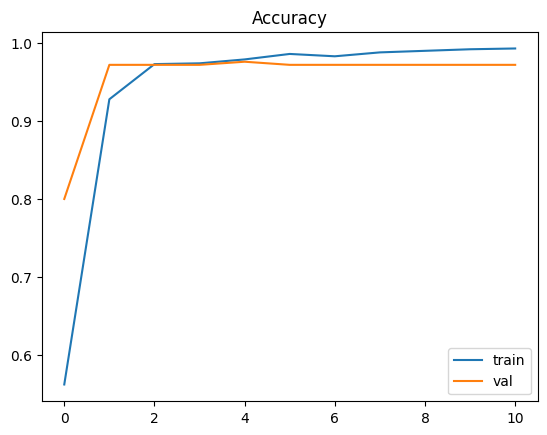

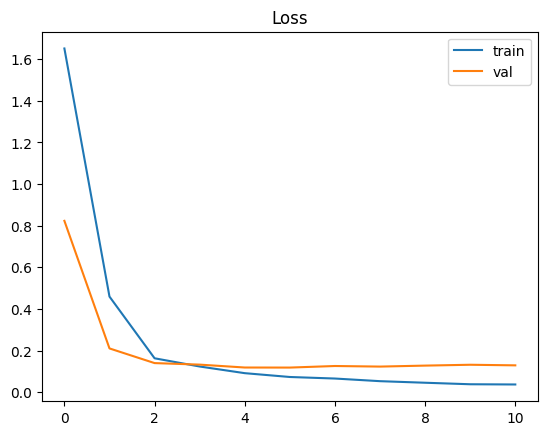

In [12]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [13]:
import time

# Đo thời gian dự đoán cho toàn bộ tập test
start_time = time.time()
y_pred_proba = model.predict(X_test)
end_time = time.time()

total_time = end_time - start_time
avg_time_per_image = total_time / len(X_test)

print(f"Tổng thời gian dự đoán: {total_time:.4f} giây")
print(f"Thời gian trung bình mỗi ảnh: {avg_time_per_image:.4f} giây")

10/10 [==============================] - 0s 2ms/step
Tổng thời gian dự đoán: 0.1089 giây
Thời gian trung bình mỗi ảnh: 0.0003 giây


In [14]:
y_pred_proba = model.predict(X_test)

10/10 [==============================] - 0s 2ms/step


In [15]:
import time
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_metrics(y_true, y_pred_probs, threshold=0.5):
    # Giả sử y_pred_probs là output của hàm model.predict()
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Tính thời gian xử lý trung bình cho 1 ảnh
    start_time = time.time()
    # (Giả lập việc trích xuất đặc trưng và dự đoán)
    end_time = time.time()
    latency = (end_time - start_time) * 1000 # tính bằng ms
    
    # Tính FAR/FRR dựa trên ma trận nhầm lẫn
    cm = confusion_matrix(y_true, y_pred)
    FP = cm.sum(axis=0) - np.diag(cm)  
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)
    
    FAR = np.mean(FP / (FP + TN))
    FRR = np.mean(FN / (TP + FN))
    
    return FAR, FRR, latency

# Gọi hàm đánh giá
far, frr, latency = evaluate_metrics(y_test, y_pred_proba)
print(f"FAR: {far:.4f}, FRR: {frr:.4f}, Latency: {latency:.2f} ms")

FAR: 0.0032, FRR: 0.0287, Latency: 0.00 ms


In [16]:
def evaluate_far_frr(y_true, y_proba, threshold=0.5):
    # Xác định class có xác suất cao nhất
    y_pred_class = np.argmax(y_proba, axis=1)
    # Lấy giá trị xác suất cao nhất đó
    max_proba = np.max(y_proba, axis=1)
    
    # Nếu xác suất < threshold, coi như model không nhận diện được (Reject)
    y_pred_final = np.where(max_proba >= threshold, y_pred_class, -1)
    
    # Tính toán FAR và FRR (logic cơ bản)
    # FRR: Người thật bị từ chối (max_proba thấp hơn threshold)
    false_rejection = np.sum((y_pred_final == -1)) 
    frr = false_rejection / len(y_true)
    
    # FAR: Người này bị nhận nhầm thành người kia
    false_acceptance = np.sum((y_pred_final != -1) & (y_pred_final != y_true))
    far = false_acceptance / len(y_true)
    
    return far, frr

# Thử nghiệm với các ngưỡng khác nhau
for t in [0.5, 0.7, 0.9]:
    far, frr = evaluate_far_frr(y_test, y_pred_proba, threshold=t)
    print(f"Threshold {t}: FAR = {far:.4f}, FRR = {frr:.4f}")

Threshold 0.5: FAR = 0.0192, FRR = 0.0224
Threshold 0.7: FAR = 0.0032, FRR = 0.0417
Threshold 0.9: FAR = 0.0000, FRR = 0.0513


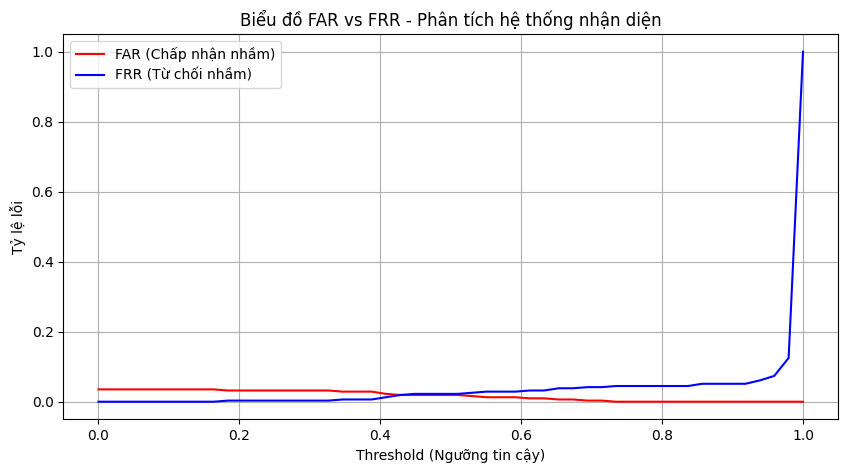

In [17]:
thresholds = np.linspace(0, 1, 50)
far_list = []
frr_list = []

for t in thresholds:
    far, frr = evaluate_far_frr(y_test, y_pred_proba, threshold=t)
    far_list.append(far)
    frr_list.append(frr)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, far_list, label='FAR (Chấp nhận nhầm)', color='red')
plt.plot(thresholds, frr_list, label='FRR (Từ chối nhầm)', color='blue')
plt.xlabel('Threshold (Ngưỡng tin cậy)')
plt.ylabel('Tỷ lệ lỗi')
plt.title('Biểu đồ FAR vs FRR - Phân tích hệ thống nhận diện')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
model.save("face_mlp.h5")

In [19]:
import pickle

with open("norm.pkl", "wb") as f:
    pickle.dump(norm, f)

In [20]:
with open("label_map.pkl", "wb") as f:
    pickle.dump(label_map, f)